# Per-mouse continuous-time GLM of pupil area

A linear model of the whole pupil-area trace of each mouse (binned to `DT`), fitted
separately per mouse with AR(1) errors. Stimulus events enter as **event kernels**: each
event type gets a lagged response function (B-spline basis over lags), so the overlapping
responses to gratings 1 s apart are deconvolved rather than averaged together.

**Data.** Pupil area / center from `acquisition/EyeTracking/pupil_tracking` and
`likely_blink` in each `*_ogen.nwb` (≈60 Hz); running speed from
`processing/running/running_speed`; stimulus table from `passiveglo_task_data.mat`;
intermissions and RF-mapping epochs from the NWB `intervals`. Only 9 of 14 mice have eye
tracking (sub-637909, sub-640507, sub-642507, sub-647836, sub-649324 do not).

**Paradigm timing.** Gratings are 0.5 s on / 0.5 s gray at 1 s SOA, 4 per trial plus a
blank slot. Block order is gloexp → rndctl → seqctl → gloexp (sub-621890: no late gloexp).
Between stimulus blocks the screen goes **black for 10 s** (`init_intermission`,
contrast −1) — a huge light-level event (≈ +4.5 SD dilation), modeled by its own kernel.

**Regressors** (see `EVENT_KERNELS` below):

| group | what | form |
|---|---|---|
| `trial_<block>` | steady-state response to a whole trial (4 gratings + blank), per block (gloexp / rndctl / seqctl), locked to trial onset | 0–5 s kernel |
| `ori_135` | every 135° grating (difference from 45°) | kernel |
| `repetition` | every grating, amplitude-modulated by z-scored `log1p(# previous presentations of that orientation in the session)` | kernel |
| `local_rndctl` | local oddball in the random control: orientation differs from the previous grating in the trial | kernel |
| `global_gloexp` | global oddball in a gloexp block: xxxx 4th grating, relative to the habitual xxxY | kernel |
| `intermission` | 10 s black-screen intermission onset (light level) | long kernel |
| `running` | \|running speed\| | lagged kernel (continuous input) |
| `gaze` | pupil-center x, y, x², y², xy (foreshortening of area by gaze angle) | concurrent |
| `time` | cubic B-spline of time in session, knots at quantiles of the fitted samples (also the intercept) | tonic |

**Why trial kernels rather than per-grating / per-position kernels.** Trials are exactly 5 s
(4 gratings at 1 s SOA + a blank slot), so within a block the impulse trains of positions
1–4 are shifted copies of one another and their separate kernels are not identifiable — only
their sum, the periodic steady-state trial response, is. That is what `trial_<block>`
captures (a 0–5 s kernel = one period; the tail of trial n overlapping trial n+1 is folded
in). Everything that *varies from trial to trial* is identifiable on top of it: orientation
(random in rndctl, by trial in seqctl), oddball status, and the slowly-changing repetition
gain.

**Status.** In gloexp every 4th grating is either the habitual change xxxY (a *local*
oddball, globally expected) or xxxx (the *global* oddball), so "local oddball in gloexp"
cannot be separated from "4th grating in gloexp" — it lives in `trial_gloexp`, and
`global_gloexp` is the xxxx-vs-xxxY contrast. In rndctl, changes occur at random positions,
so `local_rndctl` (vs. a repeated grating) is identifiable. seqctl has no within-trial
changes. The xxxx-vs-xxxY contrast also differs in the 4th grating's orientation; `ori_135`
(pinned down mainly by the random/sequence controls, where orientation varies) absorbs that
physical difference, assuming it is additive and block-invariant.

Block *tonic* offsets are not included: they are largely confounded with time in session,
which the time spline absorbs. Block enters through the evoked `grating_<block>` kernels.

**Preprocessing.** Blink / NaN / non-positive samples, and samples far (in MAD units) from
a running median (tracking glitches), are masked, padded by `BLINK_PAD`, and gaps ≤ `MAX_INTERP_GAP` linearly interpolated; longer
gaps are excluded from the fit. Area is z-scored per session over the fit window. RF-mapping
periods (+ `RF_MASK_PAD`) are excluded rather than modeled.

**Errors.** Iterated Cochrane–Orcutt AR(`AR_ORDER`, default 1), respecting gaps (no
filtering across excluded samples); the tonic level is then re-fitted by OLS. Residual ACF of the whitened residuals is reported so
the adequacy of AR(1) can be judged.

In [1]:
%cd ../..

/home/eli/AnacondaProjects/epych


In [2]:
import glob
import logging
import os
import pickle

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import scipy.interpolate
import scipy.ndimage
import scipy.signal
import scipy.stats

In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [4]:
logging.basicConfig(level=logging.INFO)

## Configuration

In [5]:
# Model time step (s). Pupil dynamics are slow; 10 Hz is ample.
DT = 0.1

# Preprocessing.
BLINK_PAD = 0.1        # s of padding around every invalid sample
MAX_INTERP_GAP = 1.0   # s; longer gaps are excluded from the fit
OUTLIER_MAD = 6.0      # robust-z threshold on the deviation from a running median
MEDIAN_WINDOW = 0.5    # s, running-median window for glitch detection
MIN_BIN_FRACTION = 0.5 # fraction of valid raw samples a bin needs

# Fit window: from the first stimulus/intermission to the last grating, plus margins.
WINDOW_PAD = 5.0
# RF-mapping epochs are excluded from the fit, plus this tail (s) for the pupil to settle.
RF_MASK_PAD = 5.0

# Lag ranges (s) and B-spline knot spacing (s) of each kernel family.
TRIAL_LAGS, TRIAL_KNOT = (0.0, 5.0), 0.5   # one trial period
STIM_LAGS, STIM_KNOT = (0.0, 4.0), 0.5
INTERMISSION_LAGS, INTERMISSION_KNOT = (-1.0, 16.0), 1.0
RUNNING_LAGS, RUNNING_KNOT = (-1.0, 5.0), 0.5
# Knot spacing (s) of the time-in-session spline.
TIME_KNOT = 60.0

# Order of the autoregressive error model (1 = AR(1)); check the whitened-residual ACF below.
AR_ORDER = 2
AR_ITERATIONS = 20
AR_TOLERANCE = 1e-5

BLOCKS = ["gloexp", "rndctl", "seqctl"]

# Grating-locked kernels: name -> (selector over the grating table, amplitude column or None,
# lag family "trial" or "stim").
EVENT_KERNELS = {
    **{"trial_%s" % b: (lambda g, b=b: (g.block == b) & (g.presentation == 1), None, "trial") for b in BLOCKS},
    "ori_135": (lambda g: g.orientation == 135, None, "stim"),
    "repetition": (lambda g: g.block != "none", "repetition_z", "stim"),
    "local_rndctl": (lambda g: (g.block == "rndctl") & (g.status == "local"), None, "stim"),
    "global_gloexp": (lambda g: (g.block == "gloexp") & (g.status == "global"), None, "stim"),
}

OUTPUT_DIR = "/mnt/data/000253/pupil_glm/"
FORCE_RECOMPUTE = False

In [6]:
NWB_SUBJECTS = sorted(glob.glob('/mnt/data/000253/sub-*/'))

## Loading

`load_gratings` re-derives per-grating factors from `passiveglo_task_data.mat`:
block, within-trial position, orientation, status (`global` = `go_gloexp` row; `local` =
orientation differs from the previous grating of the same trial; else `standard`), and the
number of previous presentations of the same orientation since the session started.

In [7]:
def load_gratings(subject_dir):
    task = scipy.io.loadmat(subject_dir + "passiveglo_task_data.mat")
    n = task["start_time"].size
    table = pd.DataFrame({k: np.asarray(v).ravel() for k, v in task.items()
                          if not k.startswith("__") and np.asarray(v).size == n})
    gratings = table[table.presentation > 0].copy().reset_index(drop=True)
    gratings["block"] = np.select([gratings.gloexp == 1, gratings.rndctl == 1, gratings.seqctl == 1],
                                  BLOCKS, "none")
    previous = gratings.groupby("trial_num").orientation.shift()
    local = previous.notna() & (gratings.orientation != previous)
    glob_odd = gratings.go_gloexp == 1
    assert not (local & glob_odd).any()
    gratings["status"] = np.where(glob_odd, "global", np.where(local, "local", "standard"))
    gratings["repetitions"] = gratings.groupby("orientation").cumcount()
    log_reps = np.log1p(gratings.repetitions)
    gratings["repetition_z"] = (log_reps - log_reps.mean()) / log_reps.std()
    return gratings

In [8]:
def find_runs(mask):
    """(start, stop) index pairs of the True runs of a boolean array."""
    padded = np.r_[False, mask, False].astype(int)
    edges = np.flatnonzero(np.diff(padded))
    return edges[0::2], edges[1::2]

def robust_outliers(x, threshold):
    med = np.nanmedian(x)
    mad = 1.4826 * np.nanmedian(np.abs(x - med))
    return np.abs(x - med) > threshold * mad

def interpolate_short_gaps(t, values, bad, max_gap):
    """Linear interpolation over runs of `bad` no longer than `max_gap` seconds (measured between
    the flanking good samples); longer runs and runs touching the edges become NaN."""
    out = values.copy()
    out[bad] = np.nan
    good = ~bad
    for start, stop in zip(*find_runs(bad)):
        if start == 0 or stop == len(t) or t[stop] - t[start - 1] > max_gap:
            continue
        for k in range(values.shape[1]):
            out[start:stop, k] = np.interp(t[start:stop], t[[start - 1, stop]], values[[start - 1, stop], k])
    return out

def load_pupil(ogen_nwb):
    """Preprocessed ~60 Hz pupil samples (t, area, x, y), or None without eye tracking."""
    with h5py.File(ogen_nwb, "r") as h:
        if "EyeTracking" not in h["acquisition"]:
            return None
        eye = h["acquisition/EyeTracking"]
        t = eye["eye_tracking/timestamps"][:]
        area = eye["pupil_tracking/area"][:]
        center = eye["pupil_tracking/data"][:]
        blink = eye["likely_blink/data"][:].astype(bool)
    keep = np.isfinite(t)
    t, area, center, blink = t[keep], area[keep], center[keep], blink[keep]

    bad = blink | ~np.isfinite(area) | (area <= 0) | ~np.isfinite(center).all(axis=1)
    fs = 1. / np.median(np.diff(t))
    # Tracking glitches: samples far from a running median of the (gap-filled) trace.
    filled = np.interp(t, t[~bad], area[~bad])
    smooth = scipy.ndimage.median_filter(filled, size=int(round(MEDIAN_WINDOW * fs)) | 1)
    bad |= robust_outliers(np.where(bad, np.nan, area - smooth), OUTLIER_MAD)
    bad = scipy.ndimage.binary_dilation(bad, iterations=max(1, int(round(BLINK_PAD * fs))))

    values = interpolate_short_gaps(t, np.column_stack([area, center]), bad, MAX_INTERP_GAP)
    logging.info("%s: %.1f%% invalid raw samples, %.1f%% left after interpolation",
                 os.path.basename(ogen_nwb), 100 * bad.mean(), 100 * np.isnan(values[:, 0]).mean())
    return pd.DataFrame({"t": t, "area": values[:, 0], "x": values[:, 1], "y": values[:, 2]})

def load_running(ogen_nwb):
    with h5py.File(ogen_nwb, "r") as h:
        running = h["processing/running/running_speed"]
        return pd.DataFrame({"t": running["timestamps"][:], "speed": running["data"][:].astype(float)})

def load_intervals(ogen_nwb, name):
    with h5py.File(ogen_nwb, "r") as h:
        if name not in h["intervals"]:
            return np.empty((0, 2))
        return np.column_stack([h["intervals"][name]["start_time"][:], h["intervals"][name]["stop_time"][:]])

In [9]:
def bin_samples(t, values, edges, min_count):
    """Mean of `values` (n, k) in each time bin; NaN where fewer than `min_count` finite samples."""
    idx = np.searchsorted(edges, t, side="right") - 1
    inside = (idx >= 0) & (idx < len(edges) - 1)
    out = np.full((len(edges) - 1, values.shape[1]), np.nan)
    for k in range(values.shape[1]):
        ok = inside & np.isfinite(values[:, k])
        counts = np.bincount(idx[ok], minlength=len(edges) - 1)
        sums = np.bincount(idx[ok], weights=values[ok, k], minlength=len(edges) - 1)
        with np.errstate(invalid="ignore", divide="ignore"):
            out[:, k] = np.where(counts >= min_count, sums / counts, np.nan)
    return out

def zscore(x, mask):
    return (x - np.nanmean(x[mask])) / np.nanstd(x[mask])

## Design matrix

Kernels use a cubic B-spline basis over lags; a lagged regressor is the convolution of an
(amplitude-weighted) impulse train, or of a continuous input, with each basis function.

In [10]:
def bspline_basis(x, lo, hi, spacing):
    """Cubic B-spline design matrix on [lo, hi] with roughly `spacing` between interior knots."""
    n_knots = max(2, int(round((hi - lo) / spacing)) + 1)
    inner = np.linspace(lo, hi, n_knots)
    knots = np.r_[[lo] * 3, inner, [hi] * 3]
    return scipy.interpolate.BSpline.design_matrix(np.clip(x, lo, hi), knots, 3).toarray()

def time_spline(times, valid):
    """Cubic B-spline of session time with knots at quantiles of the fitted samples (about one
    per TIME_KNOT seconds of valid data), so masked gaps never leave a basis unsupported."""
    fitted = times[valid]
    n_inner = max(2, int(round(len(fitted) * DT / TIME_KNOT)) + 1)
    inner = np.quantile(fitted, np.linspace(0, 1, n_inner))
    knots = np.r_[[inner[0]] * 3, inner, [inner[-1]] * 3]
    return scipy.interpolate.BSpline.design_matrix(np.clip(times, inner[0], inner[-1]), knots, 3).toarray()

def lag_basis(lags, spacing):
    lag_times = np.arange(int(round(lags[0] / DT)), int(round(lags[1] / DT)) + 1) * DT
    return lag_times, bspline_basis(lag_times, lags[0], lags[1], spacing)

def lagged(signal, lag_times, basis):
    """Columns sum_l basis[l, j] * signal[t - lag_l] for each basis function j."""
    first = int(round(lag_times[0] / DT))
    T = len(signal)
    columns = []
    for j in range(basis.shape[1]):
        full = scipy.signal.fftconvolve(signal, basis[:, j])
        index = np.arange(T) - first
        col = np.zeros(T)
        ok = (index >= 0) & (index < len(full))
        col[ok] = full[index[ok]]
        columns.append(col)
    return np.column_stack(columns)

def impulses(times, weights, t0, T):
    train = np.zeros(T)
    idx = np.round((np.asarray(times) - t0) / DT).astype(int)
    ok = (idx >= 0) & (idx < T)
    np.add.at(train, idx[ok], np.asarray(weights, dtype=float)[ok])
    return train

In [11]:
def build_design(subject_dir):
    ogen_nwb = glob.glob(subject_dir + "*_ogen.nwb")[0]
    pupil = load_pupil(ogen_nwb)
    if pupil is None:
        return None
    gratings = load_gratings(subject_dir)
    running = load_running(ogen_nwb)
    intermissions = load_intervals(ogen_nwb, "init_intermission_presentations")
    rf_mapping = load_intervals(ogen_nwb, "create_receptive_field_mapping_presentations")

    t0 = min(gratings.start_time.min(), intermissions[:, 0].min(initial=np.inf)) - WINDOW_PAD
    t1 = gratings.stop_time.max() + WINDOW_PAD
    T = int(np.ceil((t1 - t0) / DT))
    edges = t0 + DT * np.arange(T + 1)
    times = edges[:-1] + DT / 2

    fs = 1. / np.median(np.diff(pupil.t))
    eye = bin_samples(pupil.t.values, pupil[["area", "x", "y"]].values, edges, MIN_BIN_FRACTION * fs * DT)
    speed = bin_samples(running.t.values, np.abs(running[["speed"]].values), edges, 1)[:, 0]
    speed = pd.Series(speed).interpolate(limit_direction="both").values

    valid = np.isfinite(eye).all(axis=1)
    for start, stop in rf_mapping:
        valid &= ~((times >= start) & (times <= stop + RF_MASK_PAD))

    y = zscore(eye[:, 0], valid)
    gx, gy = zscore(eye[:, 1], valid), zscore(eye[:, 2], valid)

    columns, names, groups, kernels = [], [], {}, {}
    def add(group, block, kernel=None):
        start = sum(c.shape[1] for c in columns)
        columns.append(block)
        groups[group] = np.arange(start, start + block.shape[1])
        names.extend("%s[%d]" % (group, j) for j in range(block.shape[1]))
        if kernel is not None:
            kernels[group] = kernel

    families = {"trial": lag_basis(TRIAL_LAGS, TRIAL_KNOT), "stim": lag_basis(STIM_LAGS, STIM_KNOT)}
    for name, (select, amplitude, family) in EVENT_KERNELS.items():
        lags, basis = families[family]
        rows = gratings[select(gratings)]
        if len(rows) == 0:
            logging.info("%s: no events for kernel %s, dropped", subject_dir, name)
            continue
        weights = rows[amplitude].values if amplitude else np.ones(len(rows))
        add(name, lagged(impulses(rows.start_time, weights, t0, T), lags, basis), (lags, basis))

    if len(intermissions):
        lags, basis = lag_basis(INTERMISSION_LAGS, INTERMISSION_KNOT)
        add("intermission", lagged(impulses(intermissions[:, 0], np.ones(len(intermissions)), t0, T), lags, basis),
            (lags, basis))

    lags, basis = lag_basis(RUNNING_LAGS, RUNNING_KNOT)
    add("running", lagged(zscore(speed, valid), lags, basis), (lags, basis))

    add("gaze", np.column_stack([gx, gy, gx ** 2, gy ** 2, gx * gy]))
    names[-5:] = ["gaze[x]", "gaze[y]", "gaze[x2]", "gaze[y2]", "gaze[xy]"]

    valid &= np.isfinite(y) & np.isfinite(gx) & np.isfinite(gy)
    time_basis = time_spline(times, valid)
    add("time", time_basis)

    X = np.column_stack(columns)
    valid &= np.isfinite(X).all(axis=1)
    # Drop basis columns that are (numerically) all-zero on the fitted samples.
    alive = np.abs(X[valid]).max(axis=0) > 1e-10
    return {
        "subject": os.path.basename(subject_dir.rstrip("/")), "times": times, "y": y, "X": X,
        "valid": valid, "alive": alive, "names": np.array(names), "groups": groups, "kernels": kernels,
        "gratings": gratings, "intermissions": intermissions, "time_basis": time_basis,
    }

## Fitting: AR(p) GLS

Iterated Cochrane–Orcutt: estimate β by OLS on the AR-filtered data, re-estimate the AR
coefficients φ from the residuals, repeat. Filtering never crosses an excluded sample: the
first `AR_ORDER` samples of each valid segment are dropped from the filtered regression.

Near a unit root (φ ≈ 1 at 10 Hz is typical: pupil residuals have seconds of memory) GLS
barely constrains the *level* of the trace, so the time-in-session spline is afterwards
re-estimated by OLS on the partial residual `y − X_other β_other`. This fixes the tonic level
and the reported R² without touching any kernel.

In [12]:
def ar_rows(valid, order):
    """Samples whose `order` predecessors are all valid (so AR filtering stays inside a segment)."""
    ok = valid.copy()
    for k in range(1, order + 1):
        ok[k:] &= valid[:-k]
        ok[:k] = False
    return ok

def ar_filter(A, rows, phi):
    out = A[rows].copy()
    index = np.flatnonzero(rows)
    for k, coefficient in enumerate(phi, start=1):
        out -= coefficient * A[index - k]
    return out

def estimate_ar(r, rows, order):
    index = np.flatnonzero(rows)
    lags = np.column_stack([r[index - k] for k in range(1, order + 1)])
    phi, *_ = np.linalg.lstsq(lags, r[index], rcond=None)
    return phi

def fit_ar(y, X, valid, order=AR_ORDER):
    rows = ar_rows(valid, order)
    phi = np.zeros(order)
    for _ in range(AR_ITERATIONS):
        beta, *_ = np.linalg.lstsq(ar_filter(X, rows, phi), ar_filter(y, rows, phi), rcond=None)
        new_phi = estimate_ar(np.where(valid, y - X @ beta, 0.), rows, order)
        converged = np.max(np.abs(new_phi - phi)) < AR_TOLERANCE
        phi = new_phi
        if converged:
            break
    Xs, ys = ar_filter(X, rows, phi), ar_filter(y, rows, phi)
    beta, *_ = np.linalg.lstsq(Xs, ys, rcond=None)
    whitened = ys - Xs @ beta
    dof = len(ys) - X.shape[1]
    sigma2 = whitened @ whitened / dof
    covariance = sigma2 * np.linalg.pinv(Xs.T @ Xs)
    return {"beta": beta, "covariance": covariance, "phi": phi, "sigma2": sigma2, "dof": dof,
            "whitened": whitened, "condition": np.linalg.cond(Xs)}

def refit_level(y, X, valid, beta, level_idx):
    """OLS re-estimate of the level (time-spline) coefficients given all the others."""
    beta = beta.copy()
    others = np.setdiff1d(np.arange(X.shape[1]), level_idx)
    partial = y - X[:, others] @ beta[others]
    beta[level_idx], *_ = np.linalg.lstsq(X[valid][:, level_idx], partial[valid], rcond=None)
    return beta

def r_squared(y, fitted, valid):
    return 1 - np.sum((y - fitted)[valid] ** 2) / np.sum((y[valid] - y[valid].mean()) ** 2)

In [13]:
def unique_variance(y, X, valid, groups):
    """Drop in OLS R^2 (raw, un-whitened data) when each regressor group is removed."""
    def r2(A):
        beta, *_ = np.linalg.lstsq(A[valid], y[valid], rcond=None)
        res = y[valid] - A[valid] @ beta
        return 1 - res @ res / np.sum((y[valid] - y[valid].mean()) ** 2)
    full = r2(X)
    return {g: full - r2(np.delete(X, idx, axis=1)) for g, idx in groups.items() if g != "time"}

def wald(beta, covariance, idx):
    b, C = beta[idx], covariance[np.ix_(idx, idx)]
    chi2 = float(b @ np.linalg.pinv(C) @ b)
    return chi2, len(idx), scipy.stats.chi2.sf(chi2, len(idx))

def residual_acf(r, lags=(1, 2, 5, 10, 20)):
    r = r - r.mean()
    return {"acf_%d" % k: np.sum(r[k:] * r[:-k]) / np.sum(r * r) for k in lags}

In [14]:
def fit_subject(subject_dir):
    design = build_design(subject_dir)
    if design is None:
        return None
    alive = design["alive"]
    X = design["X"][:, alive]
    # Re-index groups onto the surviving columns.
    remap = -np.ones(len(alive), dtype=int)
    remap[alive] = np.arange(alive.sum())
    groups = {g: remap[idx][remap[idx] >= 0] for g, idx in design["groups"].items()}
    groups = {g: idx for g, idx in groups.items() if len(idx)}

    fit = fit_ar(design["y"], X, design["valid"])
    fit["beta"] = refit_level(design["y"], X, design["valid"], fit["beta"], groups["time"])
    beta = np.zeros(len(alive))
    beta[alive] = fit["beta"]
    covariance = np.zeros((len(alive), len(alive)))
    covariance[np.ix_(alive, alive)] = fit["covariance"]

    kernels = {}
    for g, (lags, basis) in design["kernels"].items():
        idx = design["groups"][g]
        if not alive[idx].any():
            continue
        value = basis @ beta[idx]
        se = np.sqrt(np.einsum("lj,jk,lk->l", basis, covariance[np.ix_(idx, idx)], basis))
        kernels[g] = pd.DataFrame({"lag": lags, "value": value, "se": se})

    tests = pd.DataFrame([dict(zip(["chi2", "df", "p"], wald(beta, covariance, design["groups"][g][alive[design["groups"][g]]])),
                               group=g) for g in groups if g != "time"]).set_index("group")
    tests["unique_r2"] = pd.Series(unique_variance(design["y"], X, design["valid"], groups))

    time_idx = design["groups"]["time"]
    fitted = design["X"] @ beta
    summary = {"subject": design["subject"], "r2": r_squared(design["y"], fitted, design["valid"]),
               **{"phi_%d" % (k + 1): v for k, v in enumerate(fit["phi"])},
               "n_samples": int(design["valid"].sum()), "n_regressors": int(alive.sum()),
               "condition": fit["condition"], **residual_acf(fit["whitened"])}
    return {
        "summary": summary, "kernels": kernels, "tests": tests,
        "coefficients": pd.DataFrame({"beta": beta, "se": np.sqrt(np.diag(covariance))}, index=design["names"]),
        "times": design["times"], "y": np.where(design["valid"], design["y"], np.nan),
        "fitted": np.where(design["valid"], fitted, np.nan),
        "tonic": design["time_basis"] @ beta[time_idx],
        "gratings": design["gratings"], "intermissions": design["intermissions"],
    }

## Fit every mouse

In [15]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
RESULTS = {}
for subject_dir in NWB_SUBJECTS:
    subject = os.path.basename(subject_dir.rstrip("/"))
    path = os.path.join(OUTPUT_DIR, subject + ".pickle")
    if os.path.exists(path) and not FORCE_RECOMPUTE:
        with open(path, "rb") as f:
            RESULTS[subject] = pickle.load(f)
        continue
    result = fit_subject(subject_dir)
    if result is None:
        logging.info("%s: no eye tracking, skipped", subject)
        continue
    with open(path, "wb") as f:
        pickle.dump(result, f)
    RESULTS[subject] = result
SUBJECTS = sorted(RESULTS)
len(SUBJECTS)

INFO:root:sub-637909: no eye tracking, skipped
INFO:root:sub-640507: no eye tracking, skipped
INFO:root:sub-642507: no eye tracking, skipped
INFO:root:sub-647836: no eye tracking, skipped
INFO:root:sub-649324: no eye tracking, skipped


9

INFO:root:sub-632487_ses-1204677304_ogen.nwb: 12.0% invalid raw samples, 6.1% left after interpolation


INFO:root:sub-637542_ses-1211241460_ogen.nwb: 6.0% invalid raw samples, 4.4% left after interpolation


INFO:root:sub-637908_ses-1213341633_ogen.nwb: 26.1% invalid raw samples, 20.1% left after interpolation


...

INFO:root:sub-645495_ses-1224930300_ogen.nwb: 6.3% invalid raw samples, 2.6% left after interpolation


INFO:root:sub-647836: no eye tracking, skipped


INFO:root:sub-649323_ses-1232959154_ogen.nwb: 48.8% invalid raw samples, 15.7% left after interpolation


INFO:root:sub-649324: no eye tracking, skipped


9

## Fit diagnostics

`r2` is on the raw z-scored pupil trace. `phi_k` are the fitted AR coefficients at `DT`;
`acf_k` is the autocorrelation of the *whitened* residuals at lag k bins — values far from 0
mean the AR model does not fully capture the residual dynamics and standard errors remain somewhat
optimistic (raise `AR_ORDER`).

In [16]:
pd.DataFrame([RESULTS[s]['summary'] for s in SUBJECTS]).set_index('subject').round(3)

,r2,phi_1,n_samples,n_regressors,condition,acf_1,acf_2,acf_5,acf_10,acf_20
subject,,,,,,,,,,
sub-621890,0.984,0.948,60536,227,876.247,0.045,-0.077,-0.033,0.014,0.008
sub-632485,0.833,0.991,62793,231,9215.401,0.061,-0.049,0.024,0.030,0.010
sub-632487,0.618,0.992,61956,229,12416.727,0.092,-0.040,0.039,0.024,0.005
sub-637542,0.916,0.961,60789,227,956.931,-0.051,-0.127,0.002,0.023,0.008
sub-637908,0.677,0.997,49971,209,301684.946,0.293,0.148,0.135,0.067,0.004
sub-645322,0.770,0.994,62077,229,15539.266,0.286,0.122,0.056,-0.018,-0.018
sub-645324,0.810,0.989,56051,219,3892.026,0.088,-0.002,0.011,0.020,0.001
sub-645495,0.675,0.989,62378,230,7486.243,0.208,0.075,0.046,-0.009,-0.021
sub-649323,0.965,0.927,52192,213,632.490,0.067,-0.008,-0.023,0.003,0.013


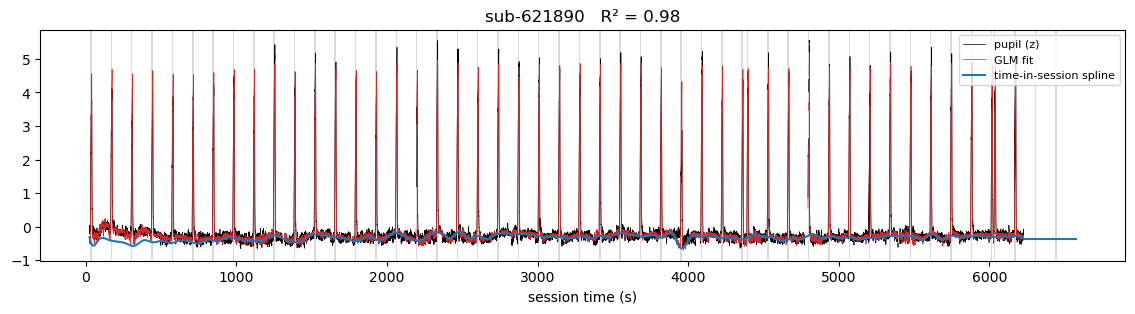

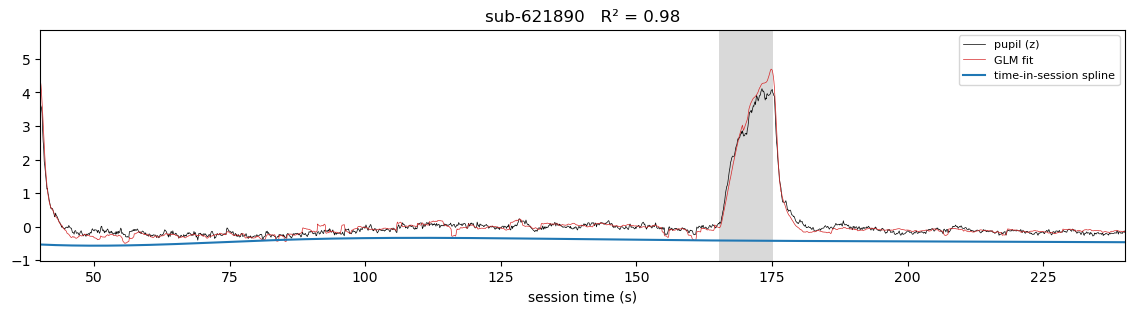

In [17]:
def plot_trace(subject, t_range=None):
    r = RESULTS[subject]
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(r["times"], r["y"], lw=0.5, color="k", label="pupil (z)")
    ax.plot(r["times"], r["fitted"], lw=0.5, color="C3", label="GLM fit")
    ax.plot(r["times"], r["tonic"], lw=1.5, color="C0", label="time-in-session spline")
    for start, stop in r["intermissions"]:
        ax.axvspan(start, stop, color="0.85", lw=0)
    if t_range is not None:
        ax.set_xlim(*t_range)
    ax.set_xlabel("session time (s)")
    ax.set_title("%s   R² = %.2f" % (subject, r["summary"]["r2"]))
    ax.legend(loc="upper right", fontsize=8)
    return fig

plot_trace(SUBJECTS[0]);
start = RESULTS[SUBJECTS[0]]["gratings"].start_time.iloc[0]
plot_trace(SUBJECTS[0], (start, start + 200));

## Kernels

Per-mouse kernels (thin, ±1 SE shading) and the across-mouse mean (thick). Units: SD of
pupil area per event (per unit z for `running`; per SD of `log1p(repetitions)` for
`repetition`).

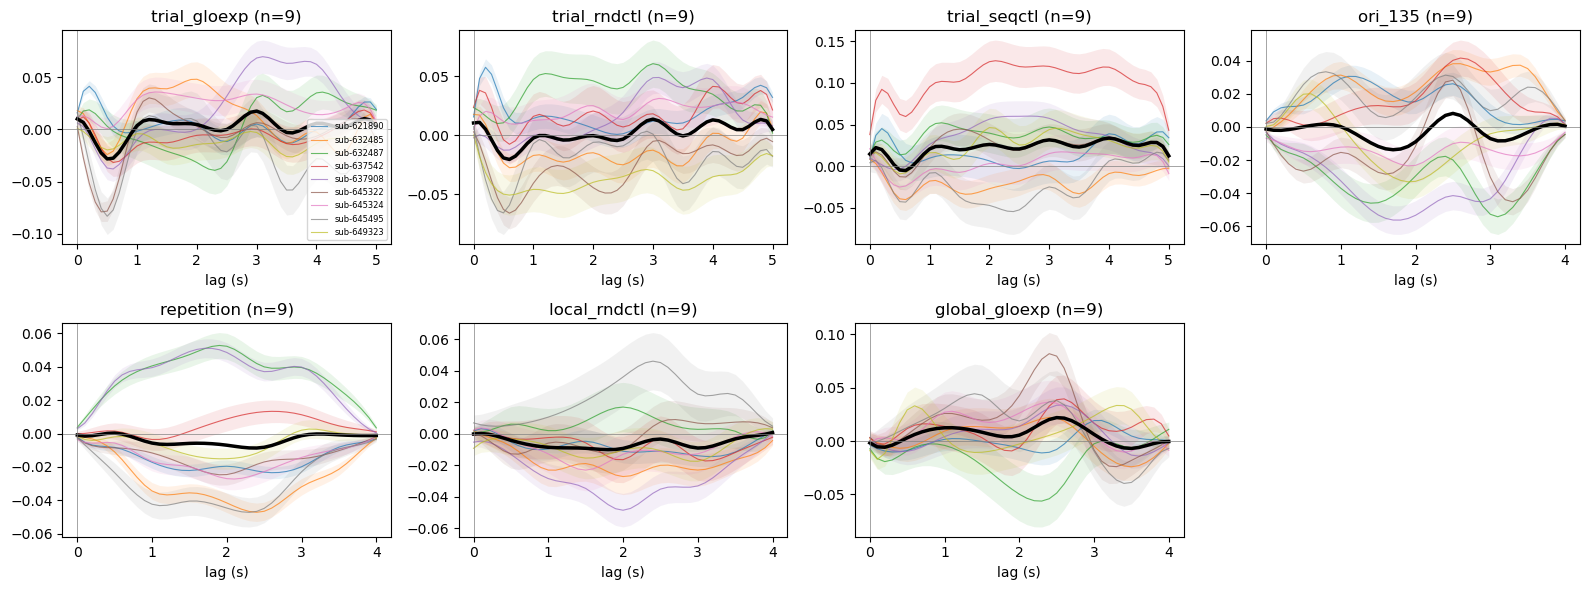

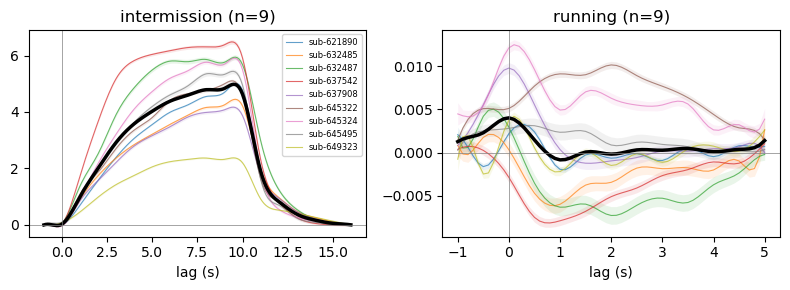

In [18]:
def plot_kernels(groups, ncols=4):
    nrows = int(np.ceil(len(groups) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False, sharex=False)
    for ax, group in zip(axes.flat, groups):
        stack = []
        for i, s in enumerate(SUBJECTS):
            k = RESULTS[s]["kernels"].get(group)
            if k is None:
                continue
            ax.plot(k.lag, k.value, lw=0.8, color="C%d" % (i % 10), alpha=0.7, label=s)
            ax.fill_between(k.lag, k.value - k.se, k.value + k.se, color="C%d" % (i % 10), alpha=0.1, lw=0)
            stack.append(k.set_index("lag").value)
        if stack:
            mean = pd.concat(stack, axis=1).mean(axis=1)
            ax.plot(mean.index, mean.values, color="k", lw=2.5)
        ax.axhline(0, color="0.5", lw=0.5)
        ax.axvline(0, color="0.5", lw=0.5)
        ax.set_title("%s (n=%d)" % (group, len(stack)))
        ax.set_xlabel("lag (s)")
    for ax in axes.flat[len(groups):]:
        ax.axis("off")
    axes.flat[0].legend(fontsize=6)
    fig.tight_layout()
    return fig

STIMULUS_GROUPS = list(EVENT_KERNELS)
plot_kernels(STIMULUS_GROUPS);
plot_kernels(["intermission", "running"], ncols=2);

## Significance and unique variance

Wald χ² test that a whole kernel (all its basis coefficients) is zero, per mouse, and the
unique R² of each group (drop in OLS R² when the group is removed). Note the Wald p-values
inherit any residual autocorrelation the AR model leaves.

In [19]:
TESTS = pd.concat({s: RESULTS[s]["tests"] for s in SUBJECTS}, names=["subject", "group"])
TESTS["significant"] = TESTS.p < 0.05
display(TESTS.p.unstack("group").map(lambda p: "%.1e" % p))
display(TESTS.unique_r2.unstack("group").round(4))
TESTS.groupby("group").significant.sum().rename("mice with p < 0.05")

group,trial_gloexp,trial_rndctl,trial_seqctl,ori_135,repetition,local_rndctl,global_gloexp,intermission,running,gaze
subject,,,,,,,,,,
sub-621890,1.4e-30,1.1e-23,4.1e-02,7.4e-11,3.1e-12,2.6e-01,1.3e-01,0.0e+00,3.6e-45,0.0e+00
sub-632485,3.8e-18,5.7e-07,1.2e-06,2.6e-10,1.3e-16,2.3e-01,2.9e-01,0.0e+00,5.8e-14,5.7e-11
sub-632487,2.3e-07,5.3e-03,4.7e-02,8.5e-08,1.4e-11,9.5e-01,6.7e-02,0.0e+00,5.6e-30,3.7e-77
sub-637542,7.8e-04,9.5e-05,5.6e-07,1.2e-02,4.9e-01,8.6e-01,1.1e-01,0.0e+00,3.0e-73,3.0e-40
sub-637908,1.3e-14,6.8e-06,2.0e-02,7.7e-17,5.9e-25,2.5e-03,2.0e-01,0.0e+00,7.2e-71,1.6e-72
sub-645322,6.8e-51,1.5e-10,4.6e-04,2.5e-23,7.0e-03,6.3e-01,7.6e-09,0.0e+00,8.8e-213,0.0e+00
sub-645324,4.2e-03,3.6e-01,2.4e-02,4.9e-02,8.8e-05,7.8e-01,1.3e-01,0.0e+00,6.9e-141,7.3e-122
sub-645495,2.2e-17,1.6e-05,3.7e-04,2.5e-04,4.2e-06,4.5e-01,1.3e-01,0.0e+00,4.7e-02,5.3e-191
sub-649323,1.7e-02,3.1e-01,4.2e-02,9.8e-03,8.7e-02,6.4e-01,2.1e-02,0.0e+00,1.2e-24,0.0e+00


group,trial_gloexp,trial_rndctl,trial_seqctl,ori_135,repetition,local_rndctl,global_gloexp,intermission,running,gaze
subject,,,,,,,,,,
sub-621890,0.0001,0.0000,0.0000,0.0003,0.0007,0.0000,0.0000,0.1691,0.0001,0.0030
sub-632485,0.0011,0.0008,0.0002,0.0044,0.0130,0.0003,0.0001,0.1870,0.0016,0.0116
sub-632487,0.0008,0.0012,0.0004,0.0041,0.0104,0.0001,0.0001,0.1569,0.0165,0.0164
sub-637542,0.0001,0.0000,0.0012,0.0000,0.0002,0.0000,0.0001,0.2544,0.0059,0.0052
sub-637908,0.0024,0.0001,0.0014,0.0060,0.0151,0.0006,0.0003,0.0719,0.0130,0.0175
sub-645322,0.0002,0.0002,0.0001,0.0001,0.0003,0.0002,0.0000,0.1200,0.0457,0.0425
sub-645324,0.0004,0.0001,0.0006,0.0006,0.0025,0.0000,0.0003,0.1721,0.0289,0.0106
sub-645495,0.0005,0.0001,0.0006,0.0017,0.0044,0.0003,0.0004,0.1549,0.0027,0.0439
sub-649323,0.0000,0.0001,0.0000,0.0001,0.0001,0.0000,0.0000,0.0304,0.0002,0.2202


group
gaze             9
global_gloexp    2
intermission     9
local_rndctl     1
ori_135          9
repetition       7
running          9
trial_gloexp     9
trial_rndctl     7
trial_seqctl     9
Name: mice with p < 0.05, dtype: int64

## Gaze coefficients and time-in-session

,gaze[x],gaze[y],gaze[x2],gaze[y2],gaze[xy]
subject,,,,,
sub-621890,-0.069,0.012,0.003,0.003,-0.008
sub-632485,-0.008,-0.000,0.000,-0.002,-0.001
sub-632487,-0.015,0.012,-0.010,0.001,0.010
sub-637542,0.010,-0.021,-0.001,-0.004,0.009
sub-637908,0.021,-0.010,-0.004,-0.001,0.001
sub-645322,-0.106,-0.007,0.020,0.001,-0.020
sub-645324,-0.012,0.012,-0.010,0.002,-0.005
sub-645495,0.012,0.033,-0.005,0.007,-0.001
sub-649323,0.170,-0.479,-0.006,0.043,-0.028


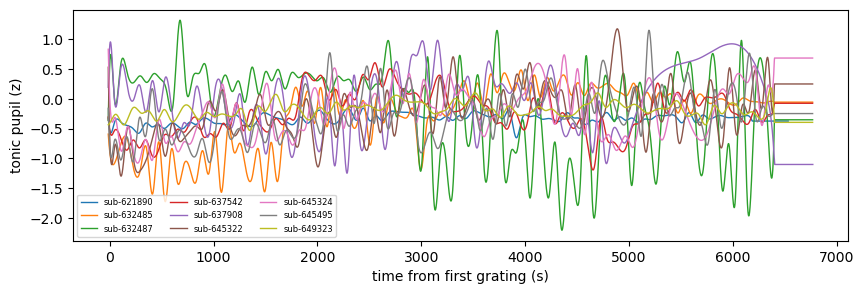

In [20]:
gaze = pd.concat({s: RESULTS[s]["coefficients"].filter(like="gaze[", axis=0) for s in SUBJECTS}, names=["subject"])
display(gaze.beta.unstack().round(3))

fig, ax = plt.subplots(figsize=(10, 3))
for i, s in enumerate(SUBJECTS):
    r = RESULTS[s]
    ax.plot(r["times"] - r["gratings"].start_time.iloc[0], r["tonic"], lw=1, label=s)
ax.set_xlabel("time from first grating (s)")
ax.set_ylabel("tonic pupil (z)")
ax.legend(fontsize=6, ncol=3)

## Next steps / options

* **Within-block repetition count**: add a column `repetitions_block = groupby(["block_index",
  "orientation"]).cumcount()` (with `block_index` the run index of contiguous blocks) to
  `load_gratings`, and a second amplitude-modulated kernel in `EVENT_KERNELS`.
* **Surprise × habituation**: an amplitude-modulated `global_gloexp` kernel with
  `repetition_z` (or the count of previous global oddballs) as amplitude.
* **Time since last global oddball** as another amplitude modulator.
* **Higher AR order** (`AR_ORDER`) if `acf_k` above stays large.